# imports

In [1]:
import mysql.connector
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Path relative to Scripts/
data_dir = Path("../Data")
input_file = data_dir / "2026-07-13_2_bank_dataset_cleaned.csv"

df = pd.read_csv(input_file, encoding="utf-8-sig", index_col=0)

print(f"Dataset loaded from: {input_file.resolve()}")
print(f"Shape: {df.shape}")

Dataset loaded from: /Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/04_Simulador/ProjecteData/Equip_32/Data/2026-07-13_2_bank_dataset_cleaned.csv
Shape: (11150, 19)


In [3]:
df = df.reset_index()  # converteix l'índex en columna normal
df.rename(columns={'index': 'id'}, inplace=True)  # per si el nom no és 'id'

In [4]:
df

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,no_previous_contact,had_previous_contact
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,1,1,0
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1373,1,-1,0,unknown,1,1,0
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1373,1,-1,0,unknown,1,1,0
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,1,1,0
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11145,11158,33.0,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,0,1,0
11146,11159,39.0,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,0,1,0
11147,11160,32.0,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,0,1,0
11148,11161,43.0,technician,married,secondary,no,0,no,yes,cellular,8,may,23,2,172,5,failure,0,0,1


# Data Transformations

# 1 Demografical clustering

## Age group

In [ ]:
# Age_group
bins   = [17, 24, 34, 44, 54, 64, 100]
labels = [
    "Jovenes (18-24)",
    "Jovenes adultos (25-34)",
    "Adultos iniciales(35-44)",
    "Adultos maduros (45-54)",
    "Mediana edad (55-64)",
    "Senior (65+)"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=True    # right-closed intervals: (17,25] includes 25
)

In [6]:
counts = df["age_group"].value_counts().sort_index()
print(counts)
print(f"\nUnassigned (NaN): {df['age_group'].isna().sum()}")

age_group
Young (18-25)           448
Young Adult (26-35)    3913
Adult (36-50)          4324
Middle-Aged (51-65)    2068
Senior (65+)            397
Name: count, dtype: int64

Unassigned (NaN): 0


In [7]:
age_summary = (
    df.groupby("age_group", observed=True)["deposit"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns={1: "pct_yes", 0: "pct_no"})
    .round(4)
)

age_summary["n_clients"] = df.groupby("age_group", observed=True).size()
print(age_summary)

deposit              pct_no  pct_yes  n_clients
age_group                                      
Young (18-25)        0.2879   0.7121        448
Young Adult (26-35)  0.5229   0.4771       3913
Adult (36-50)        0.5870   0.4130       4324
Middle-Aged (51-65)  0.5203   0.4797       2068
Senior (65+)         0.1965   0.8035        397


## Vinculacion financiera

In [8]:
# Vinculación financiera

# "unknown" is treated as 0 (no burden assumed)
# This is a deliberate modelling choice — document it in the notebook

product_map = {"yes": 1, "no": 0, "unknown": 0}

df["housing_score"]  = df["housing"].map(product_map)
df["loan_score"]     = df["loan"].map(product_map)

In [9]:
df["vinculacion"] = (
    df["housing_score"] +
    df["loan_score"] + 
    df["deposit"]
)

In [10]:
vinculacion_labels = {
    0: "0 productos",
    1: "1 producto",
    2: "multiproducto 2",
    3: "multiproducto 3"
    
}

In [11]:
vinculacion_summary = (
    df.groupby("vinculacion")["deposit"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns={1: "pct_yes", 0: "pct_no"})
    .round(4)
)

vinculacion_summary["n_clients"] = df.groupby("vinculacion").size()


print(vinculacion_summary)

deposit      pct_no  pct_yes  n_clients
vinculacion                            
0            1.0000      NaN       2119
1            0.5037   0.4963       6309
2            0.2320   0.7680       2457
3               NaN   1.0000        265


In [12]:
# Detall de productos por cliente (columna categórica, no solo el conteo)
df["housing_bin"] = (df["housing"] == "yes").astype(int)
df["loan_bin"] = (df["loan"] == "yes").astype(int)
df["deposit_bin"] = df["deposit"]  # ya es 0/1

def detalle_productos(row):
    productos = []
    if row["housing_bin"] == 1:
        productos.append("Hipoteca")
    if row["loan_bin"] == 1:
        productos.append("Préstamo")
    if row["deposit_bin"] == 1:
        productos.append("Depósito")
    return " + ".join(productos) if productos else "Ninguno"

df["productos_detalle"] = df.apply(detalle_productos, axis=1)

print(df["productos_detalle"].value_counts())

productos_detalle
Depósito                          3131
Hipoteca                          2775
Ninguno                           2119
Hipoteca + Depósito               1669
Hipoteca + Préstamo                570
Préstamo                           403
Hipoteca + Préstamo + Depósito     265
Préstamo + Depósito                218
Name: count, dtype: int64


In [13]:
#filto multiproducto
multiproducto = df[df["productos_detalle"].isin([
    "Hipoteca + Préstamo",
    "Hipoteca + Depósito",
    "Préstamo + Depósito",
    "Hipoteca + Préstamo + Depósito"
])]

## Education

In [14]:
# education

print(df["education"].value_counts())
print(f"\nUnknown count: {(df['education'] == 'unknown').sum()}")


education
secondary    5472
tertiary     3684
primary      1498
unknown       496
Name: count, dtype: int64

Unknown count: 496


In [15]:
# Ordinal scale: unknown → NaN (excluded from ranking)
# primary=1, secondary=2, tertiary=3

education_order = {
    "primary"   : 1,
    "secondary" : 2,
    "tertiary"  : 3,
    "unknown"   : None
}

df["education_rank"] = df["education"].map(education_order)

In [16]:
education_labels = {
    "primary"   : "Primary",
    "secondary" : "Secondary",
    "tertiary"  : "Tertiary",
    "unknown"   : "Unknown"
}

df["education_label"] = df["education"].map(education_labels)

In [17]:
edu_summary = (
    df.groupby("education_label")["deposit"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns={1: "pct_yes", 0: "pct_no"})
    .round(4)
)

edu_summary["n_clients"] = df.groupby("education_label").size()

# Sort by ordinal rank
order = ["Primary", "Secondary", "Tertiary", "Unknown"]
edu_summary = edu_summary.reindex(order)
print(edu_summary)

deposit          pct_no  pct_yes  n_clients
education_label                            
Primary          0.6055   0.3945       1498
Secondary        0.5528   0.4472       5472
Tertiary         0.4590   0.5410       3684
Unknown          0.4919   0.5081        496


## Jobs

In [18]:
#jobs

print(df["job"].value_counts())
print(f"\nUnknown count: {(df['job'] == 'unknown').sum()}")

job
management       2562
blue-collar      1943
technician       1821
admin.           1333
services          922
retired           777
self-employed     405
student           359
unemployed        357
entrepreneur      327
housemaid         274
unknown            70
Name: count, dtype: int64

Unknown count: 70


In [19]:
job_profile_map = {
    "admin."       : "White Collar",
    "management"   : "White Collar",
    "technician"   : "White Collar",
    "blue-collar"  : "Blue Collar",
    "housemaid"    : "Blue Collar",
    "services"     : "Blue Collar",
    "entrepreneur" : "Self-Employed",
    "self-employed": "Self-Employed",
    "retired"      : "Retired",
    "student"      : "Student",
    "unemployed"   : "Unemployed",
    "unknown"      : "Unknown"
}

df["job_profile"] = df["job"].map(job_profile_map)

In [20]:
job_summary = (
    df.groupby("job_profile")["deposit"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns={1: "pct_yes", 0: "pct_no"})
    .round(4)
)

job_summary["n_clients"] = df.groupby("job_profile").size()

order = ["White Collar", "Blue Collar", "Self-Employed", "Unemployed", "Retired", "Student", "Unknown"]
job_summary = job_summary.reindex(order)
print(job_summary)

deposit        pct_no  pct_yes  n_clients
job_profile                              
White Collar   0.5157   0.4843       5716
Blue Collar    0.6222   0.3778       3139
Self-Employed  0.5765   0.4235        732
Unemployed     0.4342   0.5658        357
Retired        0.3372   0.6628        777
Student        0.2535   0.7465        359
Unknown        0.5143   0.4857         70


In [21]:
month_map = {
    'jan': 'January', 'feb': 'February', 'mar': 'March',
    'apr': 'April', 'may': 'May', 'jun': 'June',
    'jul': 'July', 'aug': 'August', 'sep': 'September',
    'oct': 'October', 'nov': 'November', 'dec': 'December'
}
df['month'] = df['month'].map(month_map)

In [22]:
df['week_of_month'] = ((df['day'] - 1) // 7) + 1
# Resultat: 1, 2, 3, 4, 5

In [23]:
bins = [0, 3, 10, 20, 30, float('inf')]
labels = ['0-3', '4-10', '11-20', '21-30', '+30']
df['campaign_group'] = pd.cut(df['campaign'], bins=bins, labels=labels)

In [24]:
# Opció 2: Reset de l'índex com a columna neta
df = df.reset_index(drop=True)
df.index = df.index + 1  # comença des de 1 en lloc de 0


# Clusteritzacions

## ## Clusteritació amb k-prototiper directa + segments students/retired

In [25]:

# 2. Separar els segments de regla de negoci
df_rest = df[~df['job_profile'].isin(['Student', 'Retired'])].copy()

print(f"Total dataset: {len(df)}")
print(f"Excloent Student i Retired: {len(df_rest)}")
print(df['job_profile'].value_counts())

Total dataset: 11150
Excloent Student i Retired: 10014
job_profile
White Collar     5716
Blue Collar      3139
Retired           777
Self-Employed     732
Student           359
Unemployed        357
Unknown            70
Name: count, dtype: int64


In [26]:
# 3. Seleccionar variables d'identitat (sense engagementn, balance, ni variables de campanya)
cluster_vars = ['age', 'job_profile', 'education_label', 'marital']
df_cluster = df_rest[cluster_vars].copy()

# 4. Comprovar que no hi ha nulls abans d'escalar/clusteritzar
print(df_cluster.isna().sum())

# 5. Escalar age
scaler = StandardScaler()
df_cluster['age_scaled'] = scaler.fit_transform(df_cluster[['age']])

print(df_cluster[['age', 'age_scaled']].head())

age                0
job_profile        0
education_label    0
marital            0
dtype: int64
    age  age_scaled
1  59.0    1.968945
2  56.0    1.659744
3  41.0    0.113740
4  55.0    1.556677
5  54.0    1.453610


In [27]:
# 6. Preparar la matriu X: age_scaled primer, després les 3 categòriques
X = df_cluster[['age_scaled', 'job_profile', 'education_label', 'marital']].values

# 7. Indicar les posicions (índexs de columna dins de X) que són categòriques
categorical_idx = [1, 2, 3]  # job_profile, education_label, marital

print(X.shape)
print(X[:3])  # primeres 3 files, per veure que la matriu té la pinta correcta

(10014, 4)
[[1.9689451870676384 'White Collar' 'Secondary' 'married']
 [1.659744331305387 'White Collar' 'Secondary' 'married']
 [0.11374005249412972 'White Collar' 'Secondary' 'married']]


In [28]:
# 8. Elbow method: provar k de 2 a 7
costs = []
for k in range(2, 8):
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=3, random_state=42)
    kproto.fit_predict(X, categorical=categorical_idx)
    costs.append(kproto.cost_)
    print(f"k={k} -> cost={kproto.cost_:.1f}")

k=2 -> cost=9627.9
k=3 -> cost=7642.0
k=4 -> cost=6565.0
k=5 -> cost=5921.9
k=6 -> cost=5318.9
k=7 -> cost=4961.8


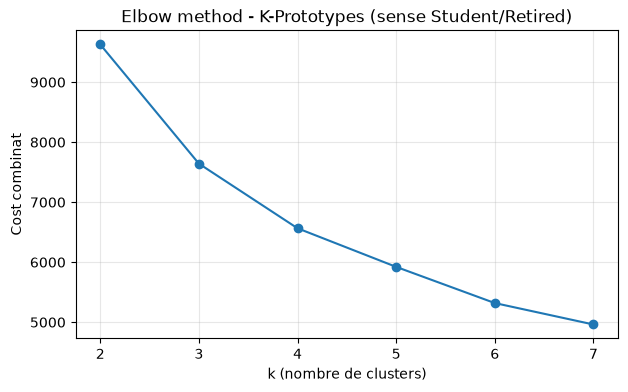

In [29]:

k_range = range(2, 8)
plt.figure(figsize=(7,4))
plt.plot(k_range, costs, marker='o')
plt.xlabel('k (nombre de clusters)')
plt.ylabel('Cost combinat')
plt.title('Elbow method - K-Prototypes (sense Student/Retired)')
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
# 9. Model final amb k=4
kproto_final = KPrototypes(n_clusters=4, init='Cao', n_init=5, random_state=42)
df_rest['cluster'] = kproto_final.fit_predict(X, categorical=categorical_idx)

print("Cost final:", kproto_final.cost_)
print(df_rest['cluster'].value_counts().sort_index())

Cost final: 6565.044587195778
cluster
0    2415
1    2880
2    2282
3    2437
Name: count, dtype: int64


In [31]:
# 10. Caracterització de cada cluster
for c in sorted(df_rest['cluster'].unique()):
    sub = df_rest[df_rest['cluster']==c]
    print(f"--- Cluster {c} (n={len(sub)}, {len(sub)/len(df_rest)*100:.1f}%) ---")
    print("age mean:", round(sub['age'].mean(),1), "| age median:", sub['age'].median())
    print("job_profile:", sub['job_profile'].value_counts(normalize=True).round(3).to_dict())
    print("education_label:", sub['education_label'].value_counts(normalize=True).round(3).to_dict())
    print("marital:", sub['marital'].value_counts(normalize=True).round(3).to_dict())
    print()

--- Cluster 0 (n=2415, 24.1%) ---
age mean: 53.7 | age median: 53.0
job_profile: {'White Collar': 0.627, 'Blue Collar': 0.235, 'Self-Employed': 0.084, 'Unemployed': 0.04, 'Unknown': 0.013}
education_label: {'Secondary': 0.454, 'Tertiary': 0.309, 'Primary': 0.168, 'Unknown': 0.069}
marital: {'married': 0.738, 'divorced': 0.178, 'single': 0.084}

--- Cluster 1 (n=2880, 28.8%) ---
age mean: 30.0 | age median: 30.0
job_profile: {'White Collar': 0.618, 'Blue Collar': 0.289, 'Self-Employed': 0.056, 'Unemployed': 0.034, 'Unknown': 0.004}
education_label: {'Secondary': 0.641, 'Tertiary': 0.297, 'Primary': 0.045, 'Unknown': 0.017}
marital: {'single': 0.752, 'married': 0.202, 'divorced': 0.046}

--- Cluster 2 (n=2282, 22.8%) ---
age mean: 36.8 | age median: 36.0
job_profile: {'White Collar': 0.847, 'Self-Employed': 0.082, 'Blue Collar': 0.046, 'Unemployed': 0.023, 'Unknown': 0.003}
education_label: {'Tertiary': 0.79, 'Secondary': 0.126, 'Primary': 0.056, 'Unknown': 0.028}
marital: {'married': 0.

In [32]:
# 11. Construir la columna 'segment' final combinant regla de negoci + clusters
df['segment'] = None
df.loc[df['job_profile']=='Student', 'segment'] = 'Student'
df.loc[df['job_profile']=='Retired', 'segment'] = 'Retired'

# Mapejar els clusters de df_rest cap a df original, usant el seu índex
df.loc[df_rest.index, 'segment'] = df_rest['cluster'].apply(lambda c: f'Cluster_{c}')

print(df['segment'].value_counts())
print()
print("Total assignat:", df['segment'].notna().sum(), "de", len(df))

segment
Cluster_1    2880
Cluster_3    2437
Cluster_0    2415
Cluster_2    2282
Retired       777
Student       359
Name: count, dtype: int64

Total assignat: 11150 de 11150


In [33]:
# Nom descriptiu de treball (provisional, pendent de validar amb Pas 2 i amb l'Elisa)
label_map = {
    'Cluster_0': 'Adultos consolidados',
    'Cluster_1': 'Trabajadores técnicos',
    'Cluster_2': 'Profesionales estudios superiores',
    'Cluster_3': 'Jovenes en consolidación',
    'Retired': 'Jubilados',
    'Student': 'Estudiantes'
}
df['segment_label'] = df['segment'].map(label_map)

print(df[['segment','segment_label']].drop_duplicates())

       segment                      segment_label
1    Cluster_0               Adultos consolidados
3    Cluster_3           Jovenes en consolidación
6    Cluster_2  Profesionales estudios superiores
8      Retired                          Jubilados
10   Cluster_1              Trabajadores técnicos
163    Student                        Estudiantes


In [34]:

print(df[['segment','segment_label']].drop_duplicates())

       segment                      segment_label
1    Cluster_0               Adultos consolidados
3    Cluster_3           Jovenes en consolidación
6    Cluster_2  Profesionales estudios superiores
8      Retired                          Jubilados
10   Cluster_1              Trabajadores técnicos
163    Student                        Estudiantes


# CSV export

In [ ]:
# Drop auto-generated index column if it was imported as a column
if "index" in df.columns:
    df = df.drop(columns=["index"])

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
 

# Drop intermediate scoring columns
cols_to_drop = [
    "housing_bin", 
    "loan_bin",
    "deposit_bin"
]

df_export = df.drop(columns=cols_to_drop)

# Export transformed dataset
output_dir = Path("../Data")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "2026-07-20_3_bank_dataset_transformed.csv"

# Export
df_export.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print(f"CSV saved to: {output_file.resolve()}")
print(f"Shape: {df_export.shape}")
print(f"Columns: {df_export.columns.tolist()}")

CSV saved to: /Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/04_Simulador/ProjecteData/Equip_32/Data/2026-07-13_3_bank_dataset_transformed.csv
Shape: (11150, 32)
Columns: ['id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit', 'no_previous_contact', 'had_previous_contact', 'age_group', 'housing_score', 'loan_score', 'vinculacion', 'productos_detalle', 'education_rank', 'education_label', 'job_profile', 'week_of_month', 'campaign_group', 'segment', 'segment_label']


In [36]:
df_export

,id,age,job,marital,education,default,balance,housing,loan,contact,...,loan_score,vinculacion,productos_detalle,education_rank,education_label,job_profile,week_of_month,campaign_group,segment,segment_label
1,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adultos consolidados
2,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,0,1,Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adultos consolidados
3,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_3,Jovenes en consolidación
4,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,Blue Collar,1,0-3,Cluster_0,Adultos consolidados
5,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,0,1,Depósito,3.0,Tertiary,White Collar,1,0-3,Cluster_0,Adultos consolidados
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11146,11158,33.0,blue-collar,single,primary,no,1,yes,no,cellular,...,0,1,Hipoteca,1.0,Primary,Blue Collar,3,0-3,Cluster_1,Trabajadores técnicos
11147,11159,39.0,services,married,secondary,no,733,no,no,unknown,...,0,0,Ninguno,2.0,Secondary,Blue Collar,3,4-10,Cluster_3,Jovenes en consolidación
11148,11160,32.0,technician,single,secondary,no,29,no,no,cellular,...,0,0,Ninguno,2.0,Secondary,White Collar,3,0-3,Cluster_1,Trabajadores técnicos
11149,11161,43.0,technician,married,secondary,no,0,no,yes,cellular,...,1,1,Préstamo,2.0,Secondary,White Collar,2,0-3,Cluster_3,Jovenes en consolidación
